In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data Preprocessing

The Titanic dataset contains missing values in the Age, Embarked, and Cabin columns. Missing Age values were replaced with the median age because the median is less affected by extreme values. Missing Embarked values were replaced with the most frequent value. The Cabin column was removed because a large proportion of its values were missing.

In [3]:
df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df = df.drop(columns=['Cabin'])

In [4]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [6]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [7]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

In [8]:
X = df[features]
y = df['Survived']

In [9]:
categorical_features = ['Sex', 'Embarked']

numerical_features = [
    'Pclass',
    'Age',
    'SibSp',
    'Parch',
    'Fare'
]

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('numerical', 'passthrough', numerical_features)
    ]
)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 712
Testing samples: 179


In [13]:
model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000))
    ]
)

In [14]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Sex', 'Embarked']),
                                                 ('numerical', 'passthrough',
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [15]:
y_pred = model.predict(X_test)

In [16]:
print(y_pred[:20])

[0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1]


In [17]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.8044692737430168
Accuracy Percentage: 80.44692737430168 %


## Model Results

A Logistic Regression model was trained to predict whether a Titanic passenger survived. The dataset was divided into 80% training data and 20% testing data, while categorical features such as Sex and Embarked were encoded using OneHotEncoder.

The model achieved a test accuracy of **80.44%**. The confusion matrix provides additional information about the model's correct predictions and classification errors. Overall, the Logistic Regression model provides a useful baseline for the Titanic survival classification problem.

In [18]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[98 12]
 [23 46]]


## Confusion Matrix Interpretation

The confusion matrix shows how well the Logistic Regression model classified passengers into survived and did not survive categories. True positives and true negatives represent correct predictions, while false positives and false negatives represent incorrect predictions. This helps us understand not only how accurate the model is, but also what types of classification errors it makes.

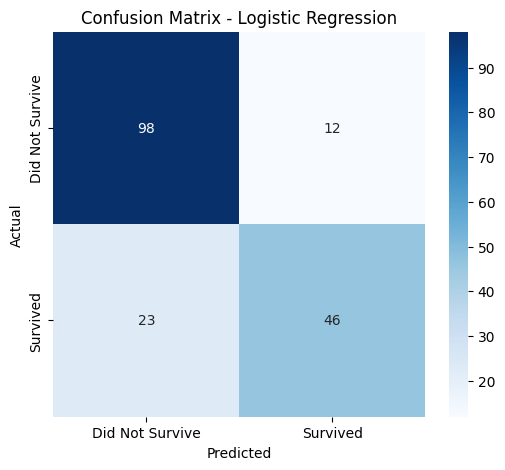

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Did Not Survive', 'Survived'],
    yticklabels=['Did Not Survive', 'Survived']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')

plt.show()